In [12]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)


In [13]:
CSV_PATH = Path("outputs/full.csv")  # Change this if you want to inspect a different export.

def parse_json_value(value):
    if pd.isna(value):
        return None
    if isinstance(value, (dict, list)):
        return value

    text = str(value).strip()
    if not text:
        return None

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return text


df_raw = pd.read_csv(CSV_PATH)
df = df_raw.copy()

json_columns = [
    "key",
    "discogs_effnet_embeddings",
    "music_styles",
    "voice_instrumental",
    "danceability",
    "clap_embeddings",
]

for column in json_columns:
    if column in df.columns:
        df[column] = df[column].apply(parse_json_value)

df["path"] = df["path"].astype(str)
df["file_name"] = df["path"].map(lambda value: Path(value).name)
df["parent_folder"] = df["path"].map(lambda value: Path(value).parent.name)

key_df = pd.json_normalize(df["key"]).add_prefix("key_") if "key" in df.columns else pd.DataFrame(index=df.index)
voice_df = pd.DataFrame(df["voice_instrumental"].tolist()).add_prefix("voice_") if "voice_instrumental" in df.columns else pd.DataFrame(index=df.index)
dance_df = pd.DataFrame(df["danceability"].tolist()).add_prefix("dance_") if "danceability" in df.columns else pd.DataFrame(index=df.index)
music_styles_df = pd.DataFrame(df["music_styles"].tolist()).fillna(0.0) if "music_styles" in df.columns else pd.DataFrame(index=df.index)

if not music_styles_df.empty:
    music_styles_df = music_styles_df.reindex(sorted(music_styles_df.columns), axis=1)

for column in ("discogs_effnet_embeddings", "clap_embeddings"):
    if column in df.columns:
        df[f"{column}_dim"] = df[column].apply(lambda values: len(values) if isinstance(values, list) else np.nan)

analysis_df = pd.concat(
    [
        df.drop(columns=[column for column in ["key", "voice_instrumental", "danceability", "music_styles"] if column in df.columns]),
        key_df,
        voice_df,
        dance_df,
    ],
    axis=1,
)

print(f"Loaded {len(analysis_df)} tracks from {CSV_PATH}")
print(f"analysis_df shape: {analysis_df.shape}")
print(f"music_styles_df shape: {music_styles_df.shape}")
# display(analysis_df.head())


Loaded 2100 tracks from outputs/full.csv
analysis_df shape: (2100, 25)
music_styles_df shape: (2100, 400)


## Styles distribution

,parent_genre,track_count,percentage
0,Rock,549,26.142857
1,Electronic,463,22.047619
2,Hip Hop,271,12.904762
3,"Folk, World, & Country",204,9.714286
4,Pop,155,7.380952
5,Latin,117,5.571429
6,Classical,86,4.095238
7,Funk / Soul,64,3.047619
8,Jazz,56,2.666667
9,Reggae,40,1.904762


,predicted_parent_genre,predicted_style,track_count,mean_activation,percentage
223,Rock,Rock---Alternative Rock,82,0.230516,3.904762
102,"Folk, World, & Country","Folk, World, & Country---Folk",77,0.220603,3.666667
271,Rock,Rock---Punk,76,0.418094,3.619048
66,Electronic,Electronic---House,61,0.396521,2.904762
29,Electronic,Electronic---Ambient,57,0.365193,2.714286
261,Rock,Rock---Pop Rock,56,0.221576,2.666667
142,Hip Hop,Hip Hop---Trap,54,0.437604,2.571429
128,Hip Hop,Hip Hop---Cloud Rap,52,0.596774,2.476190
248,Rock,Rock---Indie Rock,47,0.307813,2.238095
196,Pop,Pop---Ballad,47,0.215430,2.238095


/var/folders/3f/r_xskjpj7zz615kg232x7wjw0000gn/T/ipykernel_2589/1847210698.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


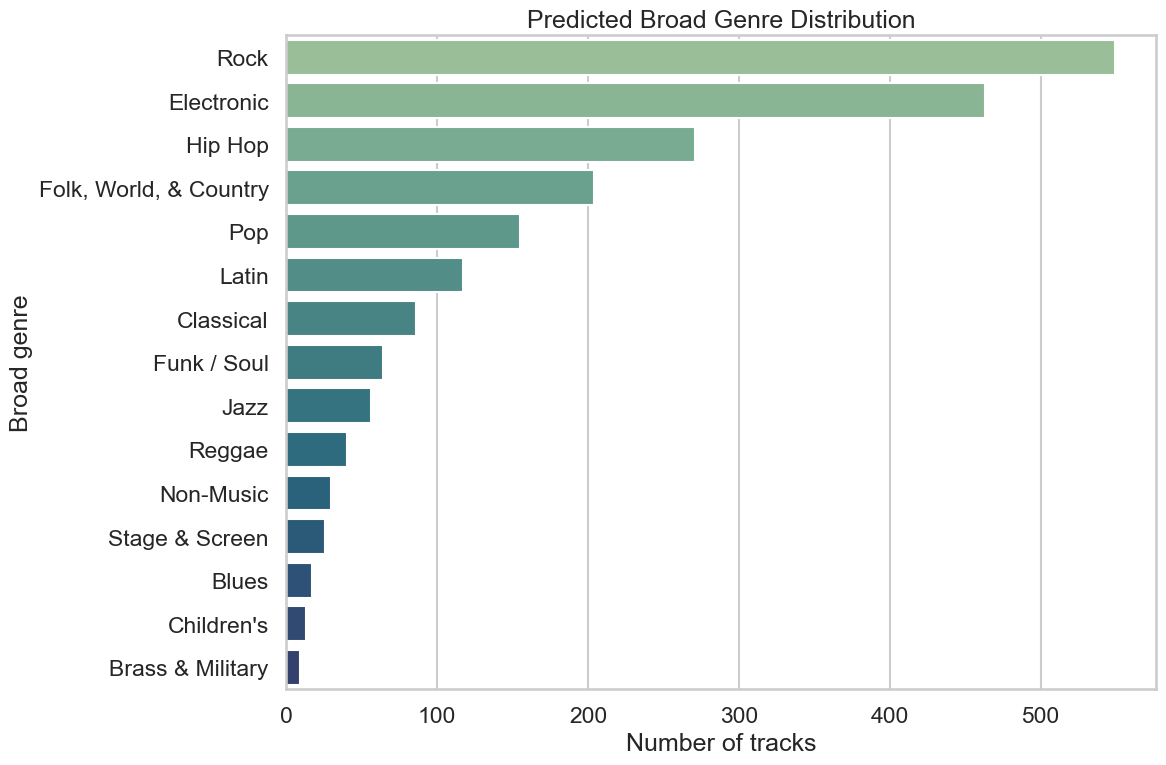

Saved full style distribution to outputs/music_style_distribution.tsv


In [14]:
# We keep a single predicted style per track by selecting the label with the highest activation.
# This makes the broad-genre distribution easy to interpret and report.

def split_style_label(label):
    for separator in ("---", "—"):
        if separator in label:
            return label.split(separator, 1)
    return label, label


predicted_style = music_styles_df.idxmax(axis=1)
predicted_style_activation = music_styles_df.max(axis=1)

style_parts = predicted_style.apply(split_style_label)
analysis_df["predicted_style"] = predicted_style
analysis_df["predicted_style_activation"] = predicted_style_activation
analysis_df["predicted_parent_genre"] = style_parts.str[0]
analysis_df["predicted_style_name"] = style_parts.str[1]

broad_genre_distribution = (
    analysis_df["predicted_parent_genre"]
    .value_counts()
    .rename_axis("parent_genre")
    .reset_index(name="track_count")
)
broad_genre_distribution["percentage"] = 100 * broad_genre_distribution["track_count"] / len(analysis_df)

style_distribution_tsv = (
    analysis_df.groupby(["predicted_parent_genre", "predicted_style"], as_index=False)
    .agg(
        track_count=("predicted_style", "size"),
        mean_activation=("predicted_style_activation", "mean"),
    )
    .sort_values(["track_count", "mean_activation"], ascending=[False, False])
)
style_distribution_tsv["percentage"] = 100 * style_distribution_tsv["track_count"] / len(analysis_df)

tsv_path = Path("outputs/music_style_distribution.tsv")
style_distribution_tsv.to_csv(tsv_path, sep="\t", index=False)

display(broad_genre_distribution)
display(style_distribution_tsv.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(
    data=broad_genre_distribution,
    x="track_count",
    y="parent_genre",
    palette="crest",
)
plt.title("Predicted Broad Genre Distribution")
plt.xlabel("Number of tracks")
plt.ylabel("Broad genre")
plt.tight_layout()
plt.show()

print(f"Saved full style distribution to {tsv_path}")


## Danceability

,tempo_bpm,danceable_score
mean,119.142041,0.582193
std,25.159107,0.395000
min,60.185352,0.000070
25%,97.524971,0.156746
50%,119.840420,0.683630
75%,136.073181,0.993054
max,184.570267,0.999999


,predicted_label,track_count,percentage
0,danceable,1193,56.809524
1,not_danceable,907,43.190476


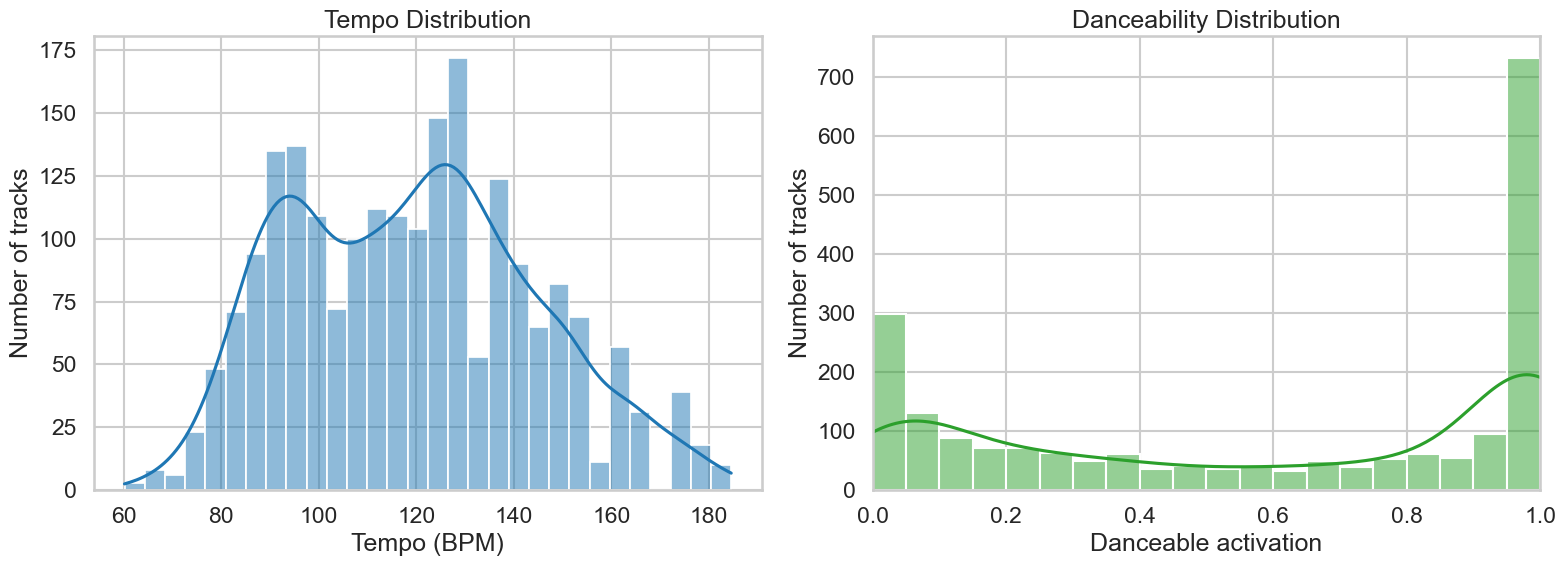

In [15]:
analysis_df["tempo_bpm"] = pd.to_numeric(analysis_df["tempo_bpm"], errors="coerce")
analysis_df["dance_danceable"] = pd.to_numeric(analysis_df["dance_danceable"], errors="coerce")

tempo_summary = analysis_df["tempo_bpm"].describe()[["mean", "std", "min", "25%", "50%", "75%", "max"]]
danceability_summary = analysis_df["dance_danceable"].describe()[["mean", "std", "min", "25%", "50%", "75%", "max"]]
danceability_label_distribution = (
    analysis_df["dance_predicted_label"]
    .value_counts()
    .rename_axis("predicted_label")
    .reset_index(name="track_count")
)
danceability_label_distribution["percentage"] = 100 * danceability_label_distribution["track_count"] / len(analysis_df)

display(pd.DataFrame({"tempo_bpm": tempo_summary, "danceable_score": danceability_summary}))
display(danceability_label_distribution)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    data=analysis_df,
    x="tempo_bpm",
    bins=30,
    kde=True,
    color="#1f77b4",
    ax=axes[0],
)
axes[0].set_title("Tempo Distribution")
axes[0].set_xlabel("Tempo (BPM)")
axes[0].set_ylabel("Number of tracks")

sns.histplot(
    data=analysis_df,
    x="dance_danceable",
    bins=20,
    kde=True,
    color="#2ca02c",
    ax=axes[1],
)
axes[1].set_title("Danceability Distribution")
axes[1].set_xlabel("Danceable activation")
axes[1].set_ylabel("Number of tracks")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()


## Keys and scales

In [16]:
key_profiles = ["temperley", "krumhansl", "edma"]
key_profile_distributions = {}

for profile in key_profiles:
    key_column = f"key_{profile}.key"
    scale_column = f"key_{profile}.scale"
    strength_column = f"key_{profile}.strength"

    analysis_df[f"{profile}_key_scale"] = (
        analysis_df[key_column].astype(str) + " " + analysis_df[scale_column].astype(str)
    )

    distribution = (
        analysis_df.groupby(f"{profile}_key_scale", as_index=False)
        .agg(
            track_count=(f"{profile}_key_scale", "size"),
            mean_strength=(strength_column, "mean"),
        )
        .sort_values(["track_count", "mean_strength"], ascending=[False, False])
    )
    distribution["percentage"] = 100 * distribution["track_count"] / len(analysis_df)
    key_profile_distributions[profile] = distribution

#for profile in key_profiles:
#    print(f"Top key/scale combinations for {profile.title()}:")
#    display(key_profile_distributions[profile].head(10))


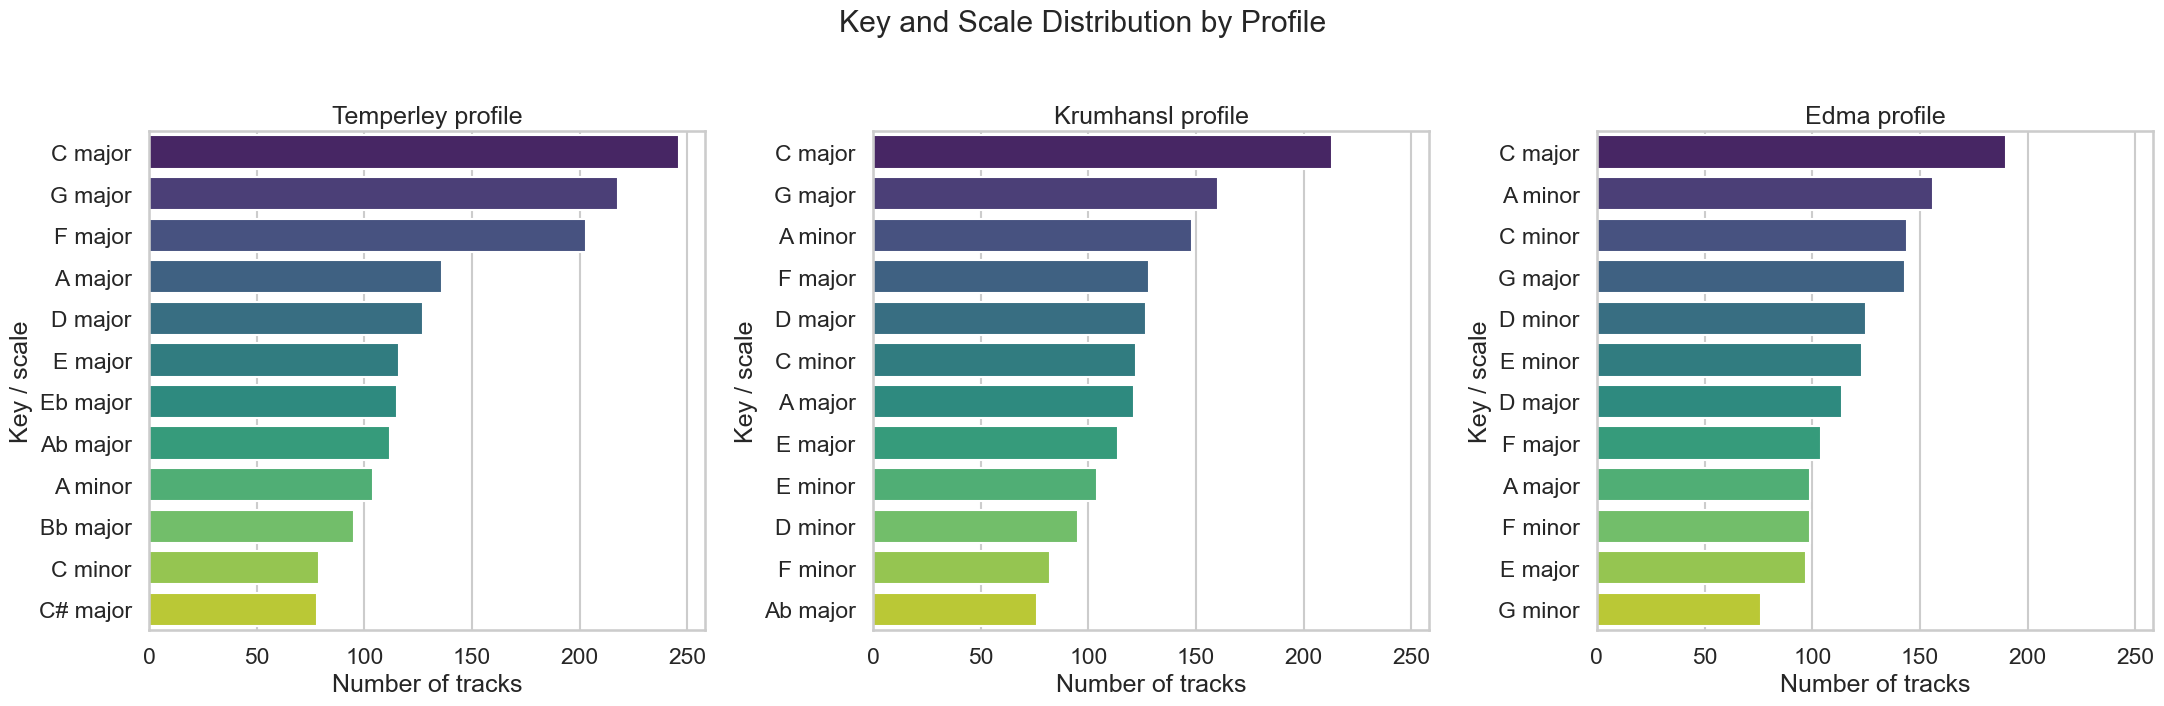

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharex=True)

for axis, profile in zip(axes, key_profiles):
    plot_df = key_profile_distributions[profile].head(12)
    sns.barplot(
        data=plot_df,
        x="track_count",
        y=f"{profile}_key_scale",
        hue=f"{profile}_key_scale",
        dodge=False,
        palette="viridis",
        legend=False,
        ax=axis,
    )
    axis.set_title(f"{profile.title()} profile")
    axis.set_xlabel("Number of tracks")
    axis.set_ylabel("Key / scale")

plt.suptitle("Key and Scale Distribution by Profile", y=1.02)
plt.tight_layout()
plt.show()


## Loudness

,loudness_lufs
mean,-10.926019
std,3.555771
min,-19.968733
25%,-13.242937
50%,-10.187606
75%,-8.225513
max,-4.980324


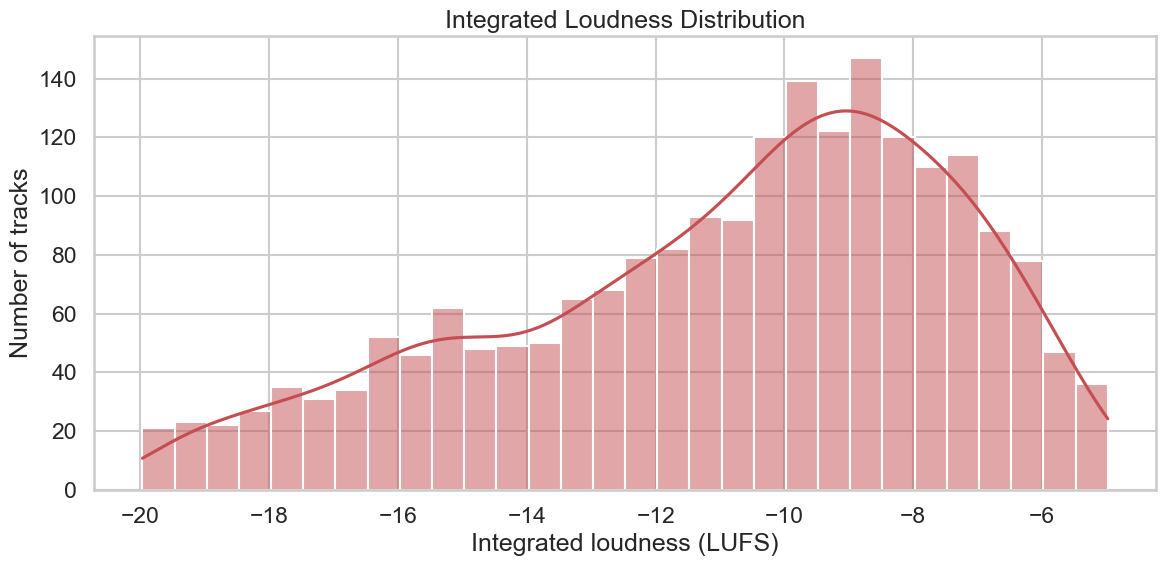

In [18]:
analysis_df["loudness_lufs"] = pd.to_numeric(analysis_df["loudness_lufs"], errors="coerce")

loudness_summary = analysis_df["loudness_lufs"].describe()[["mean", "std", "min", "25%", "50%", "75%", "max"]]
display(pd.DataFrame({"loudness_lufs": loudness_summary}))

plt.figure(figsize=(12, 6))
sns.histplot(
    data=analysis_df,
    x="loudness_lufs",
    bins=30,
    kde=True,
    color="#c44e52",
)
plt.title("Integrated Loudness Distribution")
plt.xlabel("Integrated loudness (LUFS)")
plt.ylabel("Number of tracks")
plt.tight_layout()
plt.show()


## Vocal vs instrumental

,predicted_label,track_count,percentage
0,voice,1500,71.428571
1,instrumental,600,28.571429


,mean,std,min,25%,50%,75%,max
voice_voice,0.684377,0.337927,0.000745,0.424450,0.839991,0.974123,0.999968
voice_instrumental,0.315623,0.337927,0.000032,0.025877,0.160009,0.575550,0.999255


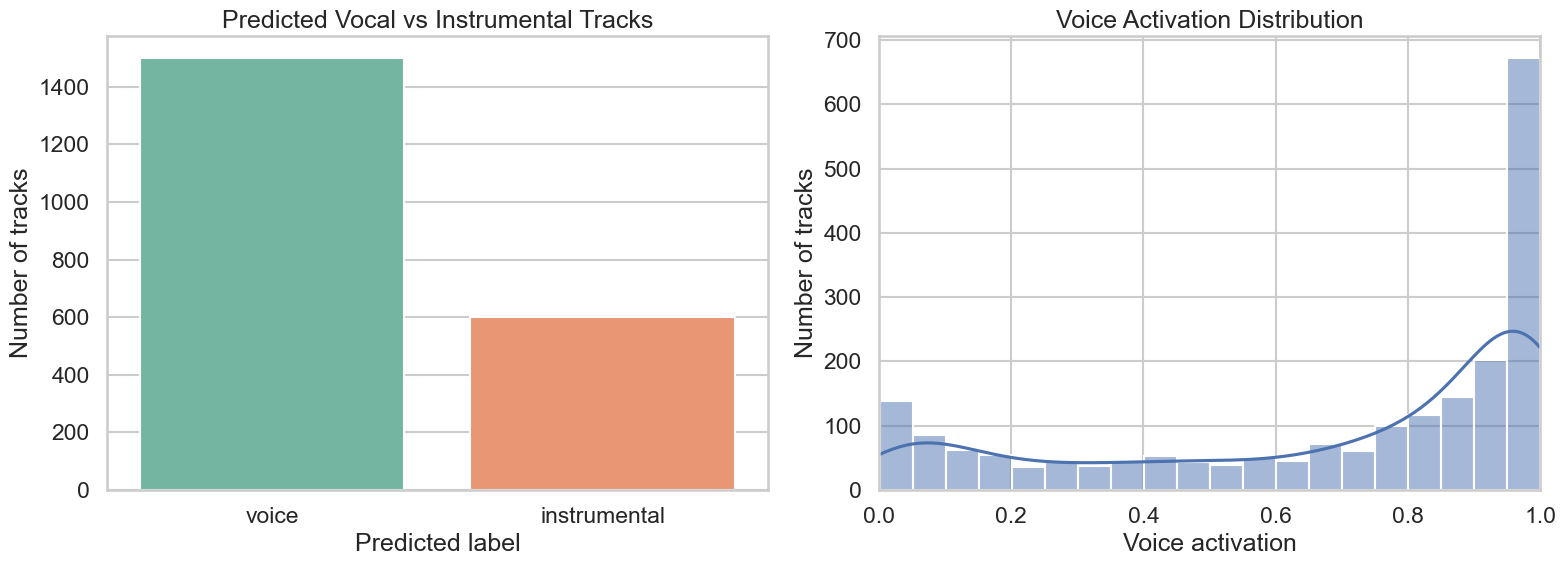

In [19]:
analysis_df["voice_voice"] = pd.to_numeric(analysis_df["voice_voice"], errors="coerce")
analysis_df["voice_instrumental"] = pd.to_numeric(analysis_df["voice_instrumental"], errors="coerce")

voice_label_distribution = (
    analysis_df["voice_predicted_label"]
    .value_counts()
    .rename_axis("predicted_label")
    .reset_index(name="track_count")
)
voice_label_distribution["percentage"] = 100 * voice_label_distribution["track_count"] / len(analysis_df)

voice_summary = analysis_df[["voice_voice", "voice_instrumental"]].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
display(voice_label_distribution)
display(voice_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=voice_label_distribution,
    x="predicted_label",
    y="track_count",
    hue="predicted_label",
    dodge=False,
    palette="Set2",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Predicted Vocal vs Instrumental Tracks")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("Number of tracks")

sns.histplot(
    data=analysis_df,
    x="voice_voice",
    bins=20,
    kde=True,
    color="#4c72b0",
    ax=axes[1],
)
axes[1].set_title("Voice Activation Distribution")
axes[1].set_xlabel("Voice activation")
axes[1].set_ylabel("Number of tracks")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()
